In [6]:
!pip install pandas matplotlib seaborn plotly  fredapi
!pip install interpret scikit-learn
!pip install xgboost
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap


In [28]:
fred = Fred(api_key='e956a3dbccd7d4f90be734f8d55b1d07')

# Features and Target
series_ids = {
    'RSAFS': 'Retail Sales: All Food Services (Target)',
    'CPIAUCSL': 'Consumer Price Index',
    'UNRATE': 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PCE': 'Personal Consumption Expenditures',
    'DSPIC96': 'Real Disposable Personal Income'
}

# Data from FRED
data = pd.DataFrame()
for series_id in series_ids:
    data[series_id] = fred.get_series(series_id)

data.index = fred.get_series('RSAFS').index

data.dropna(inplace=True)

data.rename(columns=series_ids, inplace=True)

data.reset_index(inplace=True)
data.rename(columns={'index': 'ds', 'Retail Sales: All Food Services (Target)': 'y'}, inplace=True)

In [61]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers


In [62]:
print("Outlier Detection Results (Before Model Training):")
for feature in data.columns:
    outliers = detect_outliers(data, feature)
    print(f"\nOutliers in {feature}: {len(outliers)} outliers found")
    if not outliers.empty:
        print(outliers.head())

Outlier Detection Results (Before Model Training):

Outliers in ds: 0 outliers found

Outliers in y: 0 outliers found

Outliers in Consumer Price Index: 0 outliers found

Outliers in Unemployment Rate: 9 outliers found
213    10.0
214     9.9
215     9.9
218     9.9
219     9.9
Name: Unemployment Rate, dtype: float64

Outliers in Federal Funds Rate: 0 outliers found

Outliers in Personal Consumption Expenditures: 0 outliers found

Outliers in Real Disposable Personal Income: 0 outliers found


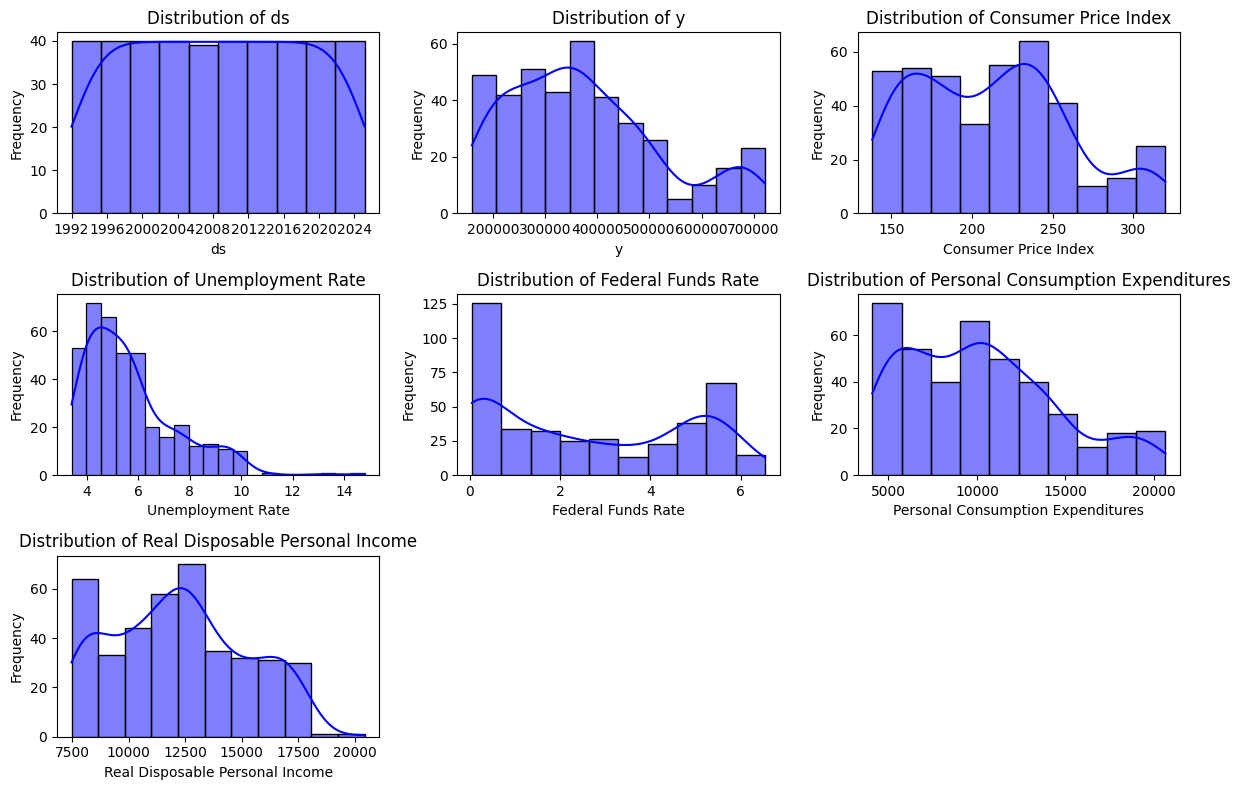

In [63]:
plt.figure(figsize=(12, 8))
num_cols = len(data.columns)
num_rows = (num_cols + 2) // 3

for i, feature in enumerate(data.columns, 1):
    plt.subplot(num_rows, 3, i)
    sns.histplot(data[feature], kde=True, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_histograms.png')

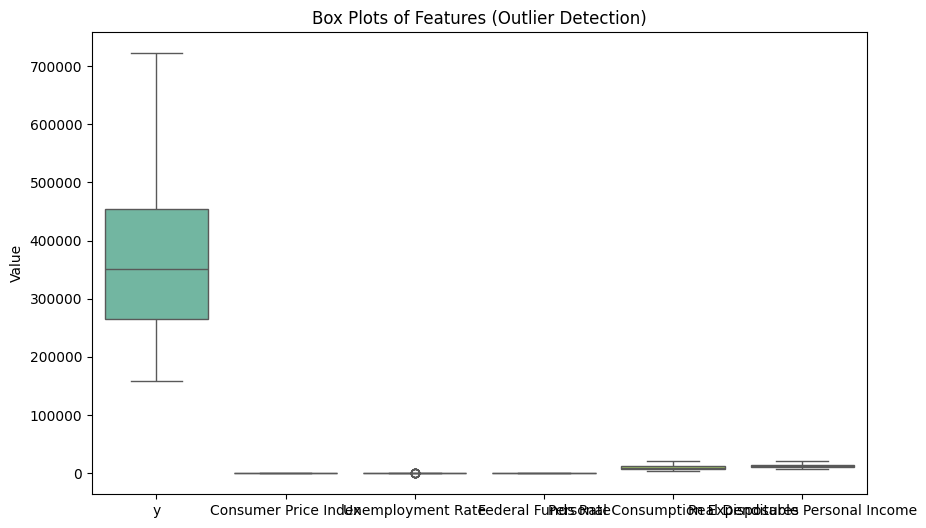

In [64]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, palette='Set2')
plt.title('Box Plots of Features (Outlier Detection)')
plt.ylabel('Value')
plt.savefig('feature_boxplots.png')


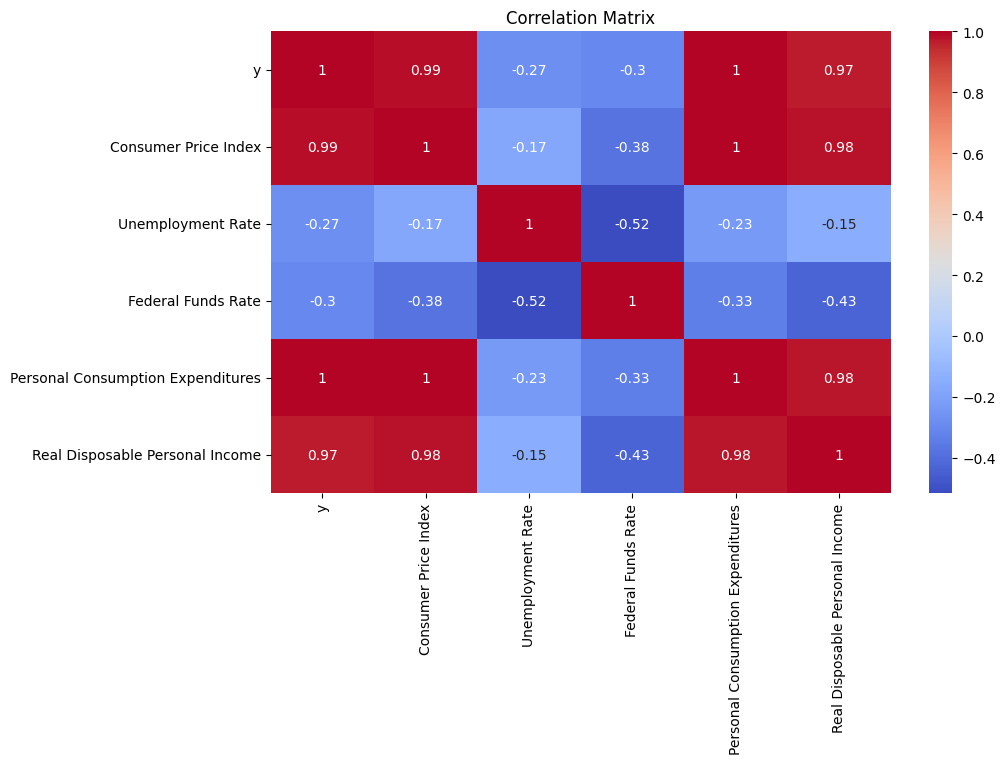

In [65]:
correlation = data.drop(columns=['ds']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

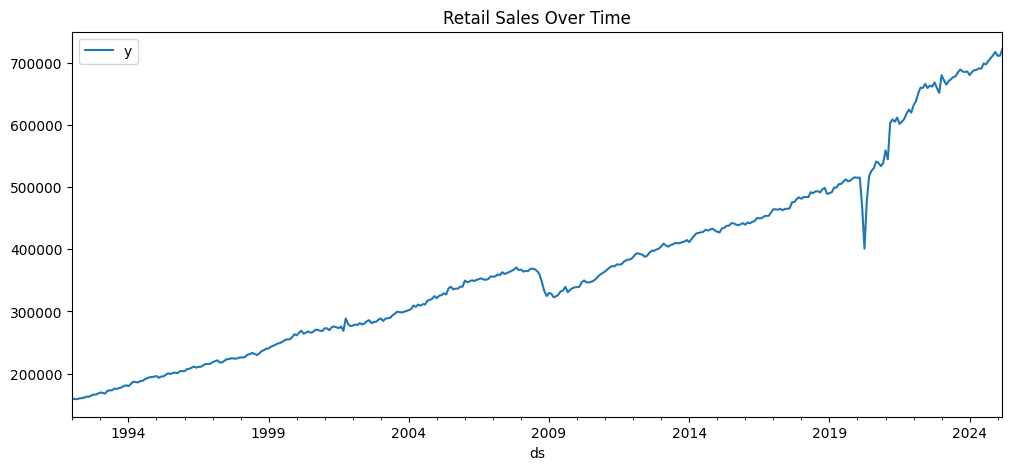

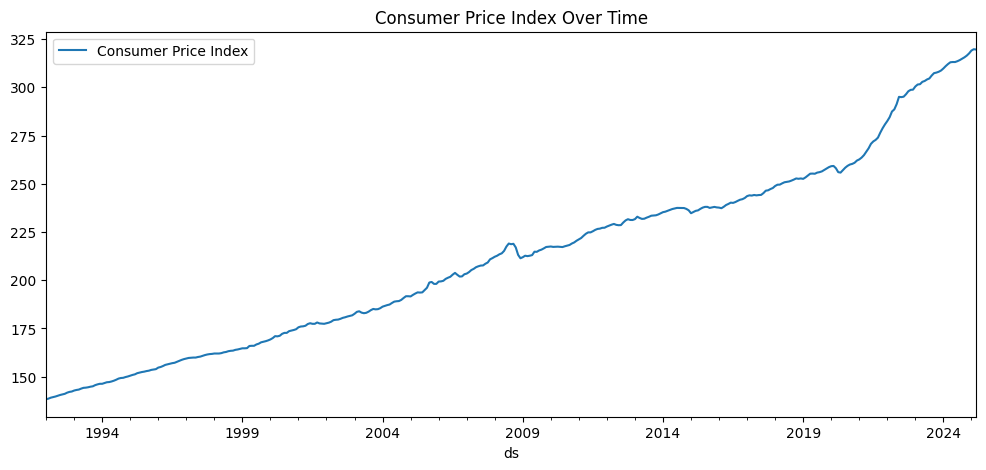

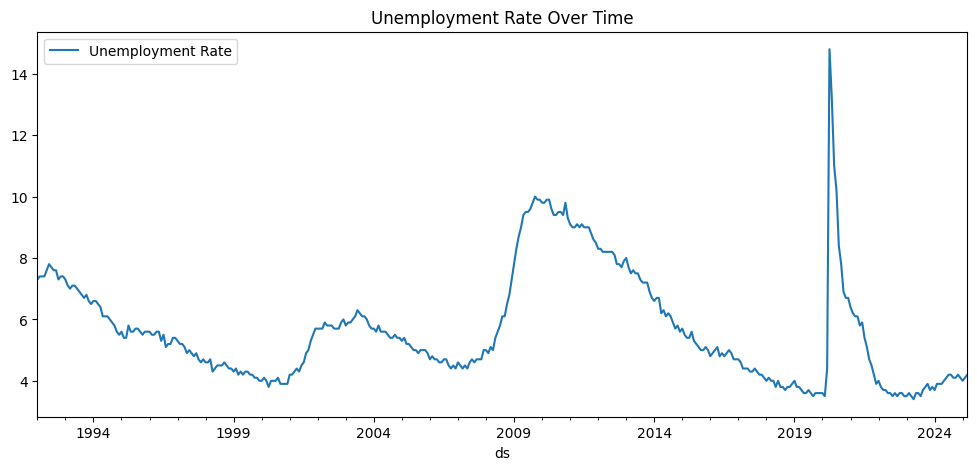

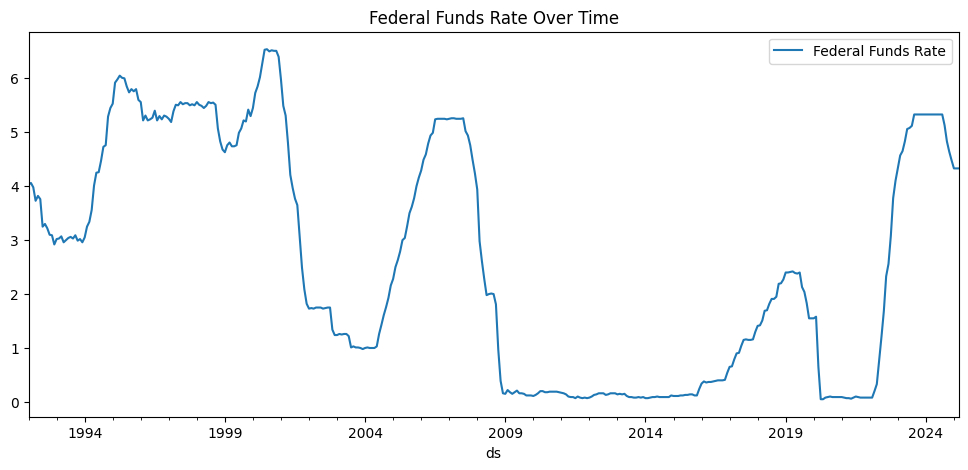

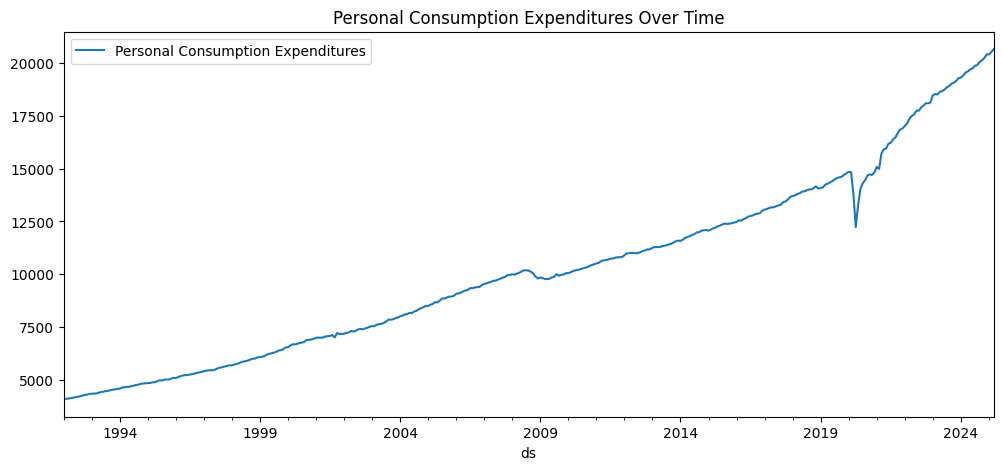

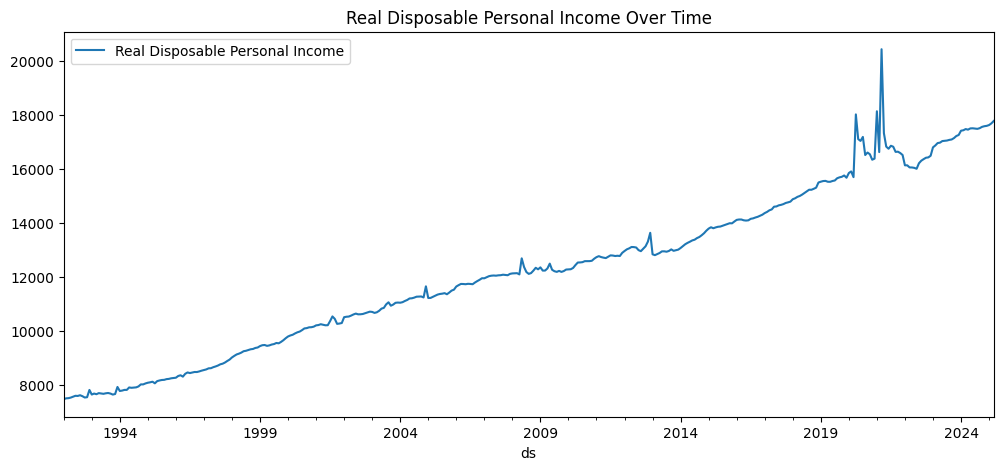

In [66]:
data.reset_index(inplace=True)

data['ds'] = pd.to_datetime(data['ds'])

data.set_index('ds', inplace=True)

data[['y']].plot(figsize=(12,5), title="Retail Sales Over Time")
plt.show()

features = ['Consumer Price Index', 'Unemployment Rate', 'Federal Funds Rate', 'Personal Consumption Expenditures', 'Real Disposable Personal Income']

for feature in features:
    data[[feature]].plot(figsize=(12,5), title=f'{feature} Over Time')
    plt.show()

In [67]:
def create_features(df, target_col, lags=3):
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    df['rolling_mean'] = df[target_col].rolling(window=3).mean()
    df['rolling_std'] = df[target_col].rolling(window=3).std()
    return df

In [71]:
df = create_features(data, 'Unemployment Rate', lags=3)
data = df.dropna()

Text(0, 0.5, 'Count')

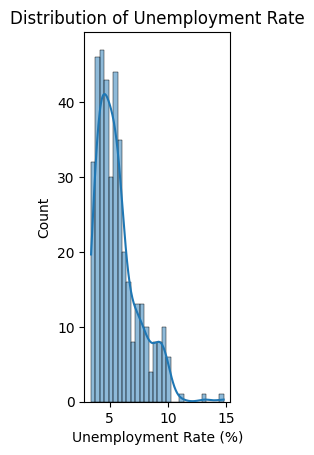

In [72]:
plt.subplot(1, 3, 1)
sns.histplot(data['Unemployment Rate'], bins=30, kde=True)
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Count')

In [73]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [75]:
X = data[['y', 'Consumer Price Index', 'Unemployment Rate', 'Federal Funds Rate', 'Personal Consumption Expenditures', 'Real Disposable Personal Income']]
y = data['Unemployment Rate']

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [77]:
print(X_train.shape, X_test.shape)

(316, 6) (80, 6)


In [78]:
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [79]:
y_pred = model.predict(X_test)


In [80]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')


RMSE: 0.6754
MAE: 0.2019


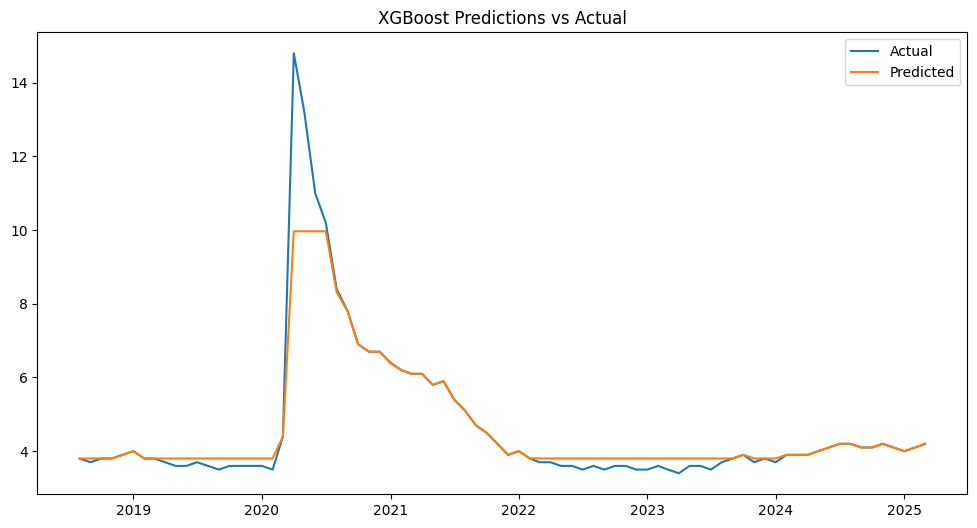

In [81]:

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.title('XGBoost Predictions vs Actual')
plt.legend()
plt.show()

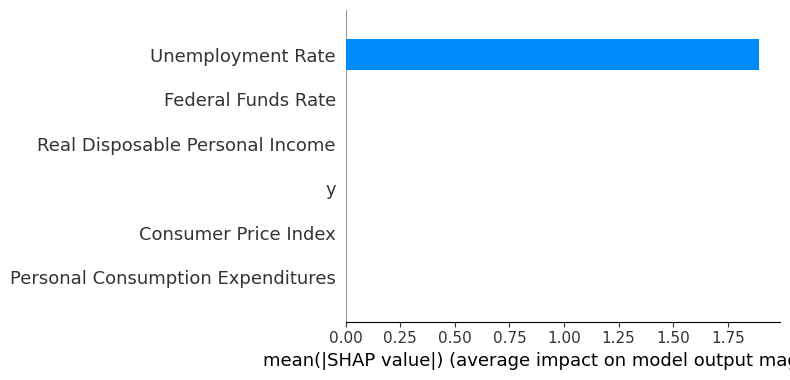

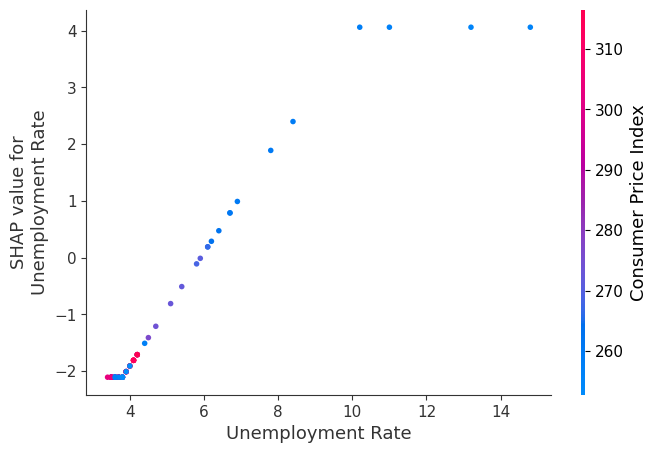

In [84]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.dependence_plot('Unemployment Rate', shap_values, X_test)  # Now lag_1 should be available in X_test


In [85]:
import lightgbm as lgb
model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 558
[LightGBM] [Info] Number of data points in the train set: 316, number of used features: 6
[LightGBM] [Info] Start training from score 5.912025
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMRegressor(max_depth=3, random_state=42)

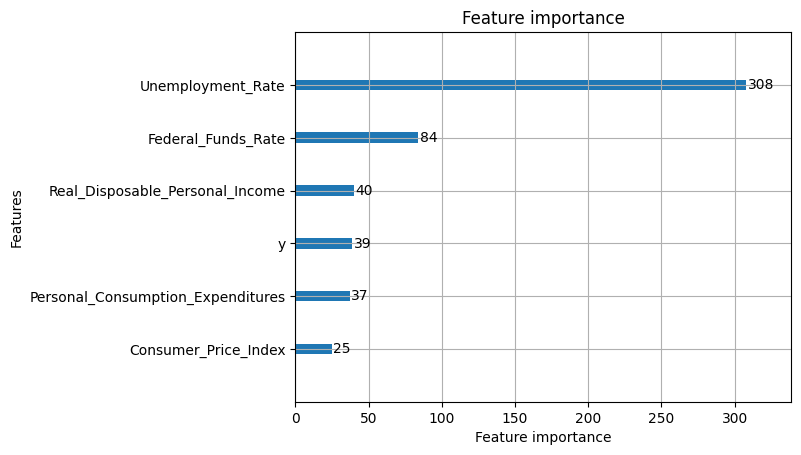

In [86]:
lgb.plot_importance(model)
plt.show()

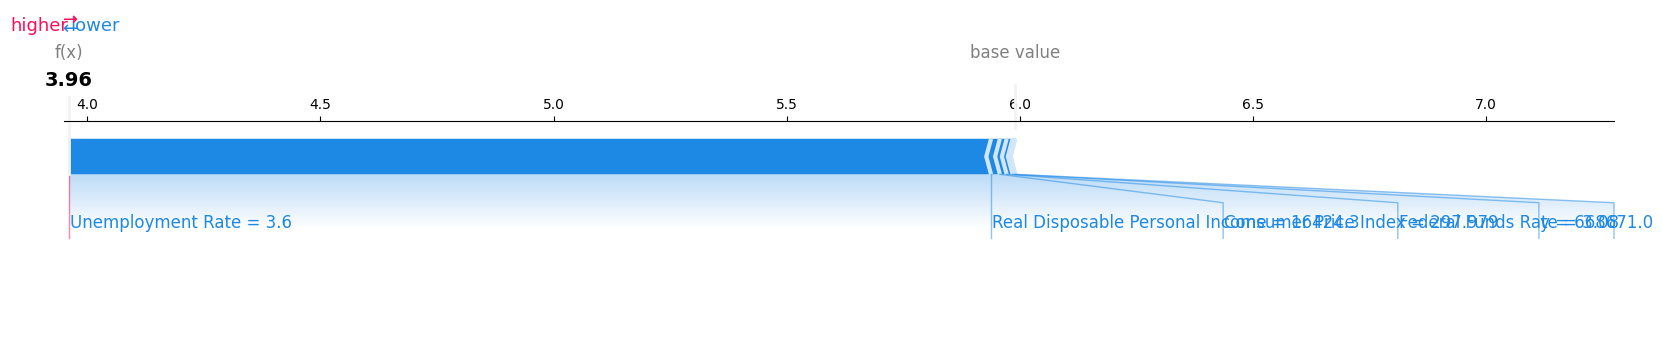

In [87]:
import shap
import pandas as pd
import numpy as np
i = 50
instance = X_test.iloc[[i]]
explainer = shap.TreeExplainer(model, data=X_train, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(instance)

shap.force_plot(explainer.expected_value, shap_values[0], instance.iloc[0], matplotlib=True)

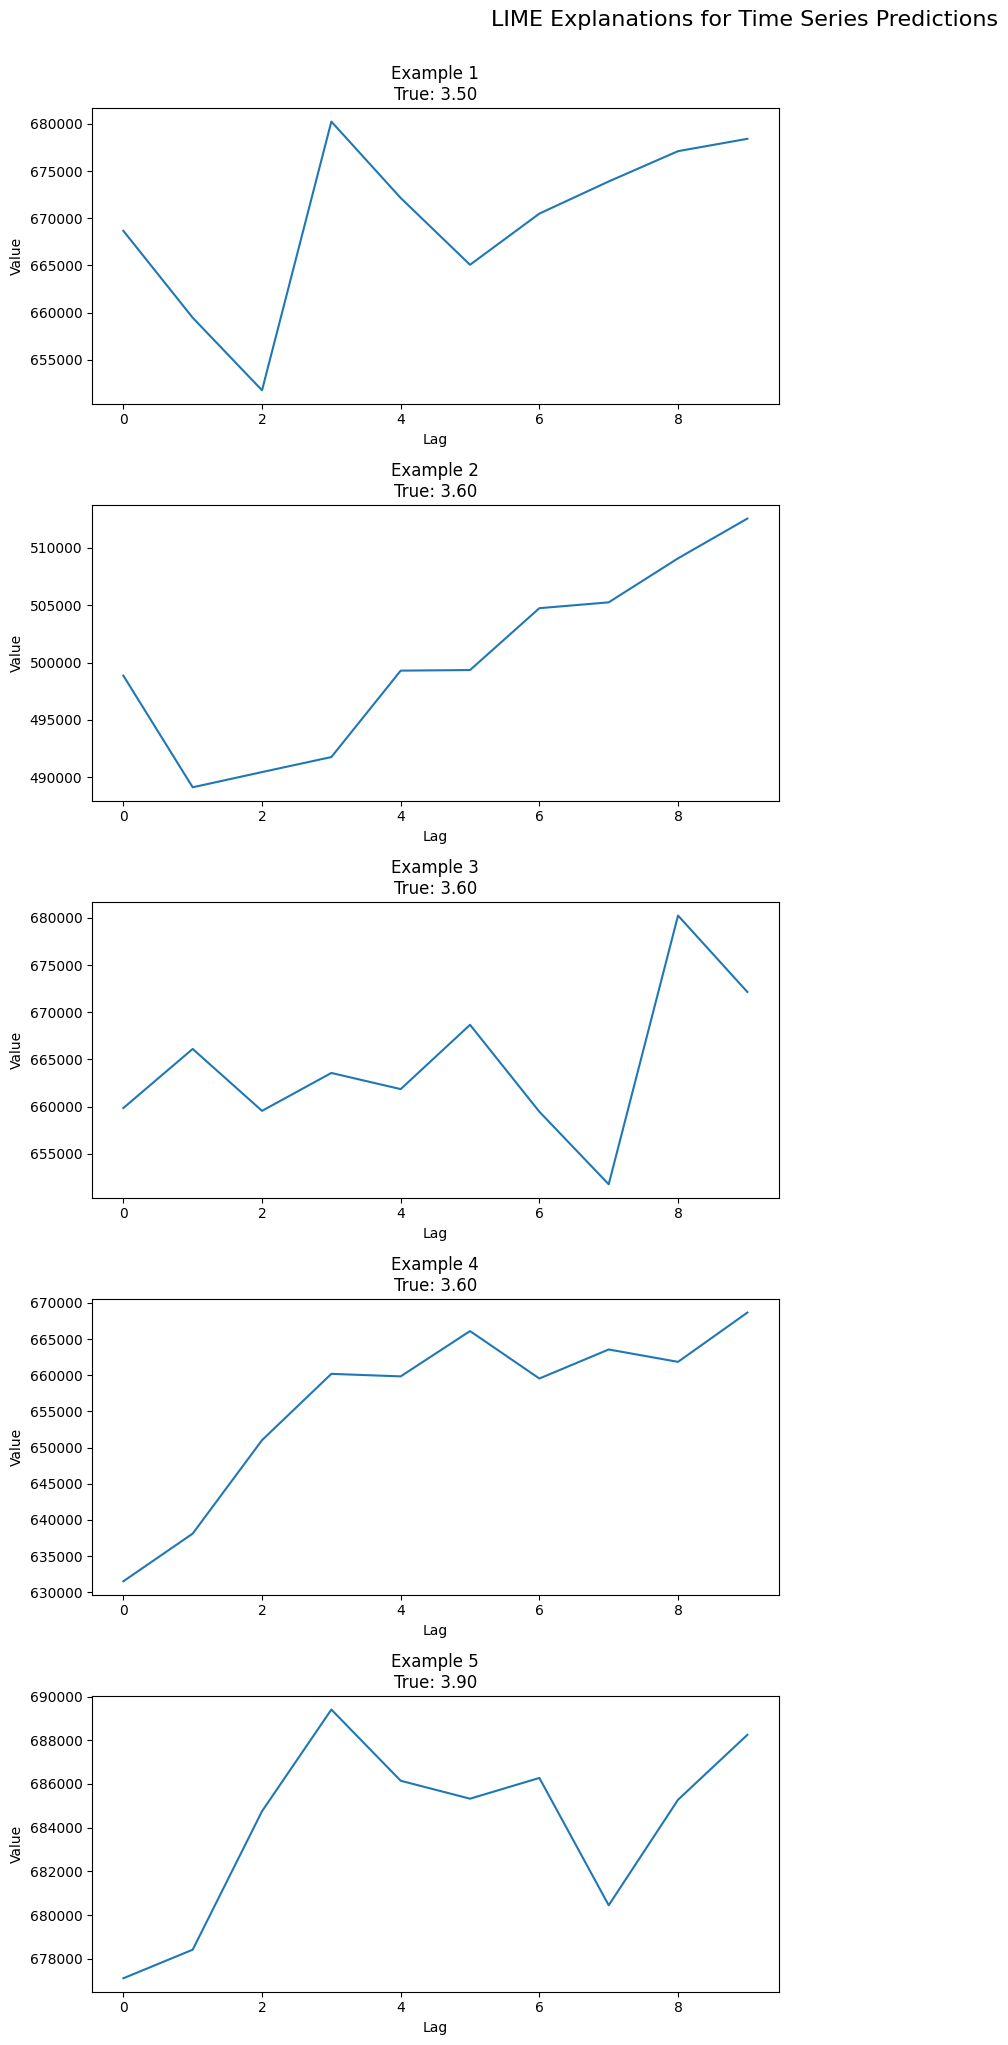

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

window_size = 10

num_examples = 5
examples = []
for i in range(num_examples):
    start_index = np.random.randint(0, len(X_test) - window_size)

    instance = X_test.iloc[start_index : start_index + window_size, 0].values

    true_value = y_test.iloc[start_index + window_size - 1]

    examples.append((instance, true_value))

plt.figure(figsize=(15, 20))
for i, (instance, true_value) in enumerate(examples):
    plt.subplot(len(examples), 2, i*2 + 1)
    plt.plot(range(window_size), instance)
    plt.title(f'Example {i+1}\nTrue: {true_value:.2f}')
    plt.xlabel("Lag")
    plt.ylabel("Value")
plt.tight_layout()
plt.suptitle("LIME Explanations for Time Series Predictions", fontsize=16, y=1.02)
plt.show()